### Attempt to Create a Regression
- Training period:  2020-01-01 → 2024-12-31  (5 years to learn patterns)
- Testing period:   2025-01-01 → 2026-06-06  (live test — did it actually work?)
##### Step 1: Capture Historical Data 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Your stock universe
stock_tickers = ['NVDA','AMD','AVGO','ARM','MU','MRVL','TSM',
                 'ASML','AMAT','LRCX','KLAC','SNPS',
                 'TXN','QCOM','INTC','ON']

ticker_group = {
    'NVDA':'AI Chip Pure Play', 'AMD':'AI Chip Pure Play',
    'AVGO':'AI Chip Pure Play', 'ARM':'AI Chip Pure Play',
    'MU':'AI Chip Pure Play',   'MRVL':'AI Chip Pure Play',
    'TSM':'AI Chip Pure Play',  'ASML':'AI Chip Enabler',
    'AMAT':'AI Chip Enabler',   'LRCX':'AI Chip Enabler',
    'KLAC':'AI Chip Enabler',   'SNPS':'AI Chip Enabler',
    'TXN':'Non-AI Control',     'QCOM':'Non-AI Control',
    'INTC':'Non-AI Control',    'ON':'Non-AI Control',
}

##### Step 2: Building Histroical Dataset 

In [9]:
def get_annual_fundamentals_v3(ticker, year):
    """
    Fixed version:
    - Handles MultiIndex price columns
    - Uses exact field names from yfinance output
    - Accounts for non-Dec fiscal year ends
    """
    try:
        stock  = yf.Ticker(ticker)
        income = stock.financials
        balance= stock.balance_sheet

        if income is None or income.empty:
            print(f'    {ticker} {year}: no income data')
            return None

        # ── Find closest fiscal year column ──────────────────────
        # Use Jan 31 of following year as target 
        # (handles NVDA fiscal year + most others)
        target = pd.Timestamp(f'{year+1}-01-31')
        col    = min(income.columns, 
                     key=lambda d: abs(d - target))
        
        # Safety check — don't use a column more than 6 months away
        if abs((col - target).days) > 180:
            print(f'    {ticker} {year}: no close fiscal year column')
            return None

        # ── Income statement fields ───────────────────────────────
        def get_field(df, names):
            """Return first matching field value at col, or None."""
            for name in names:
                if name in df.index:
                    val = df.loc[name, col]
                    if pd.notna(val) and val != 0:
                        return float(val)
            return None

        revenue      = get_field(income, ['Total Revenue', 'Operating Revenue'])
        gross_profit = get_field(income, ['Gross Profit'])
        net_income   = get_field(income, ['Net Income', 
                                          'Net Income Common Stockholders'])
        ebitda       = get_field(income, ['EBITDA', 'Normalized EBITDA'])
        
        # ── Prior year revenue for growth rate ───────────────────
        cols_sorted  = sorted(income.columns, reverse=True)
        col_idx      = cols_sorted.index(col)
        prior_col    = cols_sorted[col_idx + 1] \
                       if col_idx + 1 < len(cols_sorted) else None
        prior_rev    = None
        if prior_col is not None and 'Total Revenue' in income.index:
            pv = income.loc['Total Revenue', prior_col]
            prior_rev = float(pv) if pd.notna(pv) and pv != 0 else None

        # ── Balance sheet ─────────────────────────────────────────
        total_debt, cash = 0.0, 0.0
        if not balance.empty:
            bal_col = min(balance.columns,
                          key=lambda d: abs(d - target))
            
            def get_bal(names):
                for name in names:
                    if name in balance.index:
                        val = balance.loc[name, bal_col]
                        if pd.notna(val):
                            return float(val)
                return 0.0
            
            total_debt = get_bal(['Total Debt', 'Long Term Debt'])
            cash       = get_bal(['Cash And Cash Equivalents',
                                  'Cash Cash Equivalents And Short Term Investments',
                                  'Cash'])

        # ── Derived fundamental metrics ───────────────────────────
        rev_growth   = ((revenue / prior_rev) - 1) * 100 \
                       if revenue and prior_rev else None
        gross_margin = (gross_profit / revenue) * 100 \
                       if gross_profit and revenue else None

        # ── Price data — FIXED for MultiIndex columns ─────────────
        def get_price(tkr, start, end):
            """Download price, handle MultiIndex, return scalar."""
            df = yf.download(tkr, start=start, end=end,
                             progress=False, auto_adjust=True)
            if df.empty:
                return None
            # Handle MultiIndex: ('Close', 'NVDA') → scalar
            if isinstance(df.columns, pd.MultiIndex):
                close = df['Close'][tkr]
            else:
                close = df['Close']
            return float(close.dropna().iloc[0]) \
                   if not close.dropna().empty else None

        # Market cap at START of year
        price_jan = get_price(ticker,
                              f'{year}-01-02',
                              f'{year}-01-15')
        shares    = stock.info.get('sharesOutstanding')
        mkt_cap   = price_jan * shares \
                    if price_jan and shares else None

        # Forward return — price at start vs end of NEXT year
        # This is what we're trying to predict
        p_start = get_price(ticker,
                            f'{year+1}-01-02',
                            f'{year+1}-01-15')
        p_end   = get_price(ticker,
                            f'{year+1}-12-15',
                            f'{year+1}-12-31')
        
        # Special case for 2024 — test period ends June 2026
        if year == 2024:
            p_end = get_price(ticker,
                              '2026-05-15',
                              '2026-06-06')

        fwd_return = ((p_end / p_start) - 1) * 100 \
                     if p_start and p_end else None

        # ── Valuation ratios ──────────────────────────────────────
        ev        = (mkt_cap + total_debt - cash) \
                    if mkt_cap else None
        pe_ratio  = (mkt_cap / net_income) \
                    if mkt_cap and net_income and net_income > 0 else None
        ps_ratio  = (mkt_cap / revenue) \
                    if mkt_cap and revenue else None
        ev_ebitda = (ev / ebitda) \
                    if ev and ebitda and ebitda > 0 else None

        result = {
            'Ticker':       ticker,
            'Year':         year,
            'Group':        ticker_group.get(ticker, 'Unknown'),
            'PE_Ratio':     round(pe_ratio,  2) if pe_ratio  else None,
            'PS_Ratio':     round(ps_ratio,  2) if ps_ratio  else None,
            'EV_EBITDA':    round(ev_ebitda, 2) if ev_ebitda else None,
            'Rev_Growth':   round(rev_growth, 1) if rev_growth else None,
            'Gross_Margin': round(gross_margin,1) if gross_margin else None,
            'Fwd_Return':   round(fwd_return, 1) if fwd_return else None,
        }
        
        return result

    except Exception as e:
        import traceback
        print(f'    {ticker} {year} ERROR: {type(e).__name__}: {e}')
        print(f'    {traceback.format_exc().splitlines()[-2]}')
        return None

##### Step 3: Loop through stocks and years 

In [17]:
# ── Step 3 — Build dataset ─────────────────────────────────────────────
all_rows = []
errors   = []

for year in [2020, 2021, 2022, 2023, 2024]:
    print(f'\nYear {year}:')
    for ticker in stock_tickers:

        # Skip ARM before IPO
        if ticker == 'ARM' and year < 2023:
            continue

        print(f'  {ticker}...', end=' ', flush=True)

        row = get_annual_fundamentals_v3(ticker, year)  # ← v3 here

        if row is not None:
            all_rows.append(row)
            print(f"✓  PE={row.get('PE_Ratio')}  "
                  f"fwd={row.get('Fwd_Return')}%")
        else:
            errors.append((ticker, year))
            print('✗')

raw_df = pd.DataFrame(all_rows) if all_rows else pd.DataFrame()

print(f'\n{"="*50}')
print(f'Rows collected: {len(all_rows)}')
print(f'Errors:         {len(errors)}')
print(f'Columns:        {raw_df.columns.tolist()}')
print(raw_df.head())



Year 2020:
  NVDA...     NVDA 2020: no close fiscal year column
✗
  AMD...     AMD 2020: no close fiscal year column
✗
  AVGO...     AVGO 2020: no close fiscal year column
✗
  MU...     MU 2020: no close fiscal year column
✗
  MRVL...     MRVL 2020: no close fiscal year column
✗
  TSM...     TSM 2020: no close fiscal year column
✗
  ASML...     ASML 2020: no close fiscal year column
✗
  AMAT...     AMAT 2020: no close fiscal year column
✗
  LRCX...     LRCX 2020: no close fiscal year column
✗
  KLAC... ✓  PE=None  fwd=59.3%
  SNPS...     SNPS 2020: no close fiscal year column
✗
  TXN...     TXN 2020: no close fiscal year column
✗
  QCOM...     QCOM 2020: no close fiscal year column
✗
  INTC...     INTC 2020: no close fiscal year column
✗
  ON...     ON 2020: no close fiscal year column
✗

Year 2021:
  NVDA... ✓  PE=None  fwd=-43.7%
  AMD... ✓  PE=None  fwd=-55.7%
  AVGO... ✓  PE=None  fwd=-13.9%
  MU... ✓  PE=None  fwd=-45.4%
  MRVL... ✓  PE=None  fwd=-55.1%
  TSM... ✓  PE=None  fwd=-

$ARM: possibly delisted; no price data found  (1d 2023-01-02 -> 2023-01-15) (Yahoo error = "Data doesn't exist for startDate = 1672635600, endDate = 1673758800")

1 Failed download:
['ARM']: possibly delisted; no price data found  (1d 2023-01-02 -> 2023-01-15) (Yahoo error = "Data doesn't exist for startDate = 1672635600, endDate = 1673758800")


✓  PE=None  fwd=110.4%
  MU... ✓  PE=None  fwd=31.9%
  MRVL... ✓  PE=None  fwd=115.3%
  TSM... ✓  PE=0.43  fwd=102.0%
  ASML... ✓  PE=26.2  fwd=1.6%
  AMAT... ✓  PE=10.88  fwd=10.6%
  LRCX... ✓  PE=13.1  fwd=4.9%
  KLAC... ✓  PE=17.25  fwd=18.1%
  SNPS... ✓  PE=49.77  fwd=4.6%
  TXN... ✓  PE=20.59  fwd=15.1%
  QCOM... ✓  PE=14.45  fwd=14.8%
  INTC... ✓  PE=76.7  fwd=-55.8%
  ON... ✓  PE=10.97  fwd=-18.4%

Year 2024:
  NVDA... ✓  PE=15.98  fwd=63.0%
  AMD... ✓  PE=137.7  fwd=251.6%
  AVGO... ✓  PE=85.07  fwd=85.3%
  ARM... ✓  PE=92.94  fwd=63.2%
  MU... ✓  PE=118.41  fwd=732.9%
  MRVL... ✓  PE=None  fwd=56.4%
  TSM... ✓  PE=0.44  fwd=103.9%
  ASML... ✓  PE=35.73  fwd=117.2%
  AMAT... ✓  PE=16.74  fwd=169.4%
  LRCX... ✓  PE=17.13  fwd=297.1%
  KLAC... ✓  PE=17.67  fwd=186.2%
  SNPS... ✓  PE=42.21  fwd=4.1%
  TXN... ✓  PE=29.88  fwd=69.1%
  QCOM... ✓  PE=13.84  fwd=34.9%
  INTC... ✓  PE=None  fwd=437.9%
  ON... ✓  PE=20.13  fwd=83.3%

Rows collected: 61
Errors:         16
Columns:        

##### Step 4: Clean and Prepare Data 

In [20]:
FEATURES = ['PE_Ratio', 'PS_Ratio', 'EV_EBITDA', 'Rev_Growth', 'Gross_Margin']
TARGET   = 'Fwd_Return'

# First always check what you have
print(f"Raw rows collected: {len(raw_df)}")
print(f"Columns: {raw_df.columns.tolist()}")
print(f"\nMissing values:")
print(raw_df.isnull().sum())
print(f"\nSample data:")
print(raw_df.head(10))

Raw rows collected: 61
Columns: ['Ticker', 'Year', 'Group', 'PE_Ratio', 'PS_Ratio', 'EV_EBITDA', 'Rev_Growth', 'Gross_Margin', 'Fwd_Return']

Missing values:
Ticker           0
Year             0
Group            0
PE_Ratio        18
PS_Ratio        13
EV_EBITDA       13
Rev_Growth      27
Gross_Margin    12
Fwd_Return       0
dtype: int64

Sample data:
  Ticker  Year              Group  PE_Ratio  PS_Ratio  EV_EBITDA  Rev_Growth  \
0   KLAC  2020    AI Chip Enabler       NaN       NaN        NaN         NaN   
1   NVDA  2021  AI Chip Pure Play       NaN       NaN        NaN         NaN   
2    AMD  2021  AI Chip Pure Play       NaN       NaN        NaN         NaN   
3   AVGO  2021  AI Chip Pure Play       NaN       NaN        NaN         NaN   
4     MU  2021  AI Chip Pure Play       NaN       NaN        NaN         NaN   
5   MRVL  2021  AI Chip Pure Play       NaN       NaN        NaN         NaN   
6    TSM  2021  AI Chip Pure Play       NaN       NaN        NaN         NaN   
7   

In [21]:
# Drop rows missing target or any feature
model_df = raw_df.dropna(subset=[TARGET] + FEATURES).copy()

print(f"Rows before cleaning: {len(raw_df)}")
print(f"Rows after dropping NaN: {len(model_df)}")

# Remove extreme outliers that would dominate the regression
# These are real values but statistically they pull the line unfairly
before = len(model_df)
model_df = model_df[
    (model_df['PE_Ratio']  < 500) &
    (model_df['PE_Ratio']  > 0)   &
    (model_df['EV_EBITDA'] < 400) &
    (model_df['EV_EBITDA'] > 0)   &
    (model_df['PS_Ratio']  < 100) &
    (model_df['PS_Ratio']  > 0)
]
print(f"Rows after outlier removal: {len(model_df)}")
print(f"Rows removed as outliers: {before - len(model_df)}")
print(f"\nData by year:")
print(model_df['Year'].value_counts().sort_index())
print(f"\nData by group:")
print(model_df['Group'].value_counts())
print(f"\nFeature summary stats:")
print(model_df[FEATURES + [TARGET]].describe().round(2))

Rows before cleaning: 61
Rows after dropping NaN: 29
Rows after outlier removal: 27
Rows removed as outliers: 2

Data by year:
Year
2022     2
2023    12
2024    13
Name: count, dtype: int64

Data by group:
Group
AI Chip Enabler      12
AI Chip Pure Play     8
Non-AI Control        7
Name: count, dtype: int64

Feature summary stats:
       PE_Ratio  PS_Ratio  EV_EBITDA  Rev_Growth  Gross_Margin  Fwd_Return
count     27.00     27.00      27.00       27.00         27.00       27.00
mean      39.64      6.68      20.09       16.11         56.97       96.20
std       38.50      3.89      14.69       35.37         15.15      152.89
min       10.88      2.39       7.71      -19.00         22.40      -55.80
25%       16.01      4.04      12.14       -5.20         47.20        7.75
50%       19.19      5.18      13.78        7.90         55.70       63.00
75%       45.99      8.84      21.92       23.80         62.95      125.00
max      137.70     18.37      70.89      125.90         97.00   

##### Step 5: Split into train and test 

In [22]:
# Training: fundamentals from 2020-2023 predicting 2021-2024 returns
# Testing:  fundamentals from 2024 predicting 2025-2026 returns

train_df = model_df[model_df['Year'] <= 2023].copy()
test_df  = model_df[model_df['Year'] == 2024].copy()

print(f'Training samples: {len(train_df)}')
print(f'Testing samples:  {len(test_df)}')
print(f'\nTraining target distribution:')
print(train_df[TARGET].describe().round(1))
print(f'\nTesting target distribution:')
print(test_df[TARGET].describe().round(1))

# Separate features and target
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

# Scale features — important for regression
# Each feature is on different scale (PE is 30x, margins are 0-100%)
# Scaling puts them all on same footing
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # use SAME scaler as training

print('\nFeatures scaled ✓')
print('(StandardScaler: each feature → mean=0, std=1)')

Training samples: 14
Testing samples:  13

Training target distribution:
count     14.0
mean      31.4
std       61.9
min      -55.8
25%        2.4
50%       12.7
75%       47.5
max      174.1
Name: Fwd_Return, dtype: float64

Testing target distribution:
count     13.0
mean     165.9
std      190.6
min        4.1
25%       63.2
50%       85.3
75%      186.2
max      732.9
Name: Fwd_Return, dtype: float64

Features scaled ✓
(StandardScaler: each feature → mean=0, std=1)


##### Step 6: Run Regression

In [23]:
# Before running multi-variable regression
# check each feature individually — which ones have signal?

print('Individual feature regressions vs forward return:')
print('=' * 65)
print(f'{"Feature":<20} {"Slope":>8} {"R²":>8} {"p-value":>10} {"Signal"}')
print('-' * 65)

single_results = {}

for feature in FEATURES:
    x = train_df[feature].values
    y = train_df[TARGET].values
    
    # Remove any remaining NaN pairs
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    
    slope, intercept, r_val, p_val, se = stats.linregress(x, y)
    r2 = r_val ** 2
    
    signal = '✓ significant' if p_val < 0.05 else \
             '~ marginal'    if p_val < 0.10 else \
             '✗ weak'
    
    single_results[feature] = {
        'slope': slope, 'r2': r2, 'p_value': p_val
    }
    
    print(f'{feature:<20} {slope:>8.3f} {r2:>8.3f} {p_val:>10.4f}  {signal}')

print()
print('R² interpretation:')
print('  0.00–0.05 = very weak signal')
print('  0.05–0.15 = weak but real')
print('  0.15–0.35 = moderate — useful')
print('  0.35+     = strong')

Individual feature regressions vs forward return:
Feature                 Slope       R²    p-value Signal
-----------------------------------------------------------------
PE_Ratio               -0.795    0.170     0.1427  ✗ weak
PS_Ratio                5.877    0.057     0.4107  ✗ weak
EV_EBITDA              -1.708    0.051     0.4373  ✗ weak
Rev_Growth              1.183    0.481     0.0060  ✓ significant
Gross_Margin            2.725    0.280     0.0518  ~ marginal

R² interpretation:
  0.00–0.05 = very weak signal
  0.05–0.15 = weak but real
  0.15–0.35 = moderate — useful
  0.35+     = strong


##### Step 7: Run Multiple Regression

In [24]:
# Multiple regression — all features together
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred = model.predict(X_train_scaled)
train_r2     = r2_score(y_train, y_train_pred)
train_mae    = mean_absolute_error(y_train, y_train_pred)

# Test performance — the real question
y_test_pred  = model.predict(X_test_scaled)
test_r2      = r2_score(y_test, y_test_pred)
test_mae     = mean_absolute_error(y_test, y_test_pred)

print('Multiple regression results:')
print('=' * 50)
print(f'\nTraining performance (2020-2023):')
print(f'  R²:  {train_r2:.3f}')
print(f'  MAE: {train_mae:.1f}%  (average prediction error)')

print(f'\nTest performance (2024 → 2025 returns):')
print(f'  R²:  {test_r2:.3f}')
print(f'  MAE: {test_mae:.1f}%')

print(f'\nFeature coefficients (scaled):')
print(f'  (positive = higher value predicts higher return)')
print(f'  (negative = higher value predicts lower return)')
for feat, coef in zip(FEATURES, model.coef_):
    direction = '↑' if coef > 0 else '↓'
    print(f'  {feat:<20} {coef:>8.3f}  {direction}')

print(f'\n  Intercept: {model.intercept_:.2f}%')

Multiple regression results:

Training performance (2020-2023):
  R²:  0.676
  MAE: 24.9%  (average prediction error)

Test performance (2024 → 2025 returns):
  R²:  -0.620
  MAE: 154.9%

Feature coefficients (scaled):
  (positive = higher value predicts higher return)
  (negative = higher value predicts lower return)
  PE_Ratio               11.696  ↑
  PS_Ratio               30.556  ↑
  EV_EBITDA             -49.328  ↓
  Rev_Growth             24.794  ↑
  Gross_Margin           17.956  ↑

  Intercept: 31.44%


##### Step 8: Visualize Predictions vs Actual 

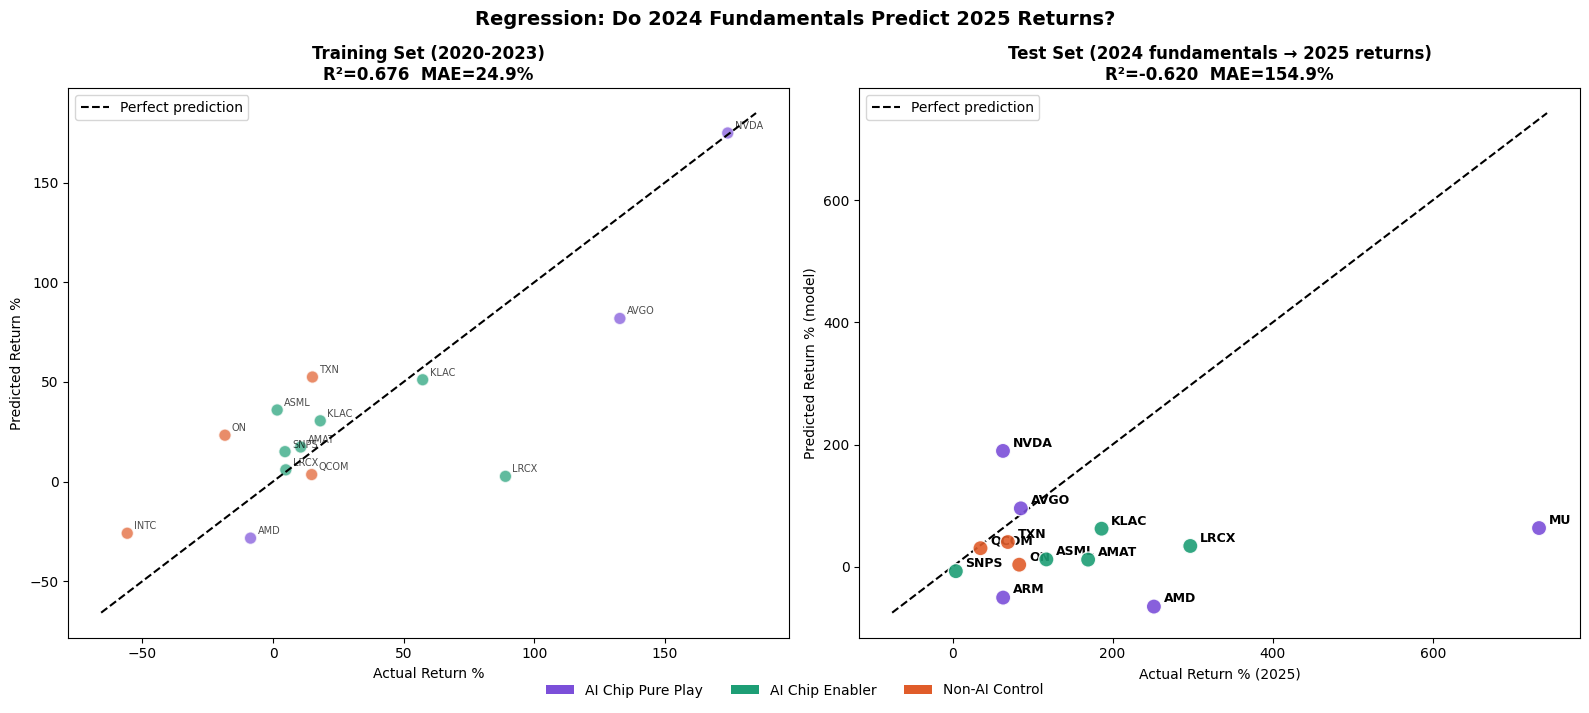

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1: Training fit ──────────────────────────────────────────────
ax = axes[0]
colors_train = [{'AI Chip Pure Play':'#7B4FD9',
                 'AI Chip Enabler':'#1D9E75',
                 'Non-AI Control':'#E05C2A'}.get(g,'gray')
                for g in train_df['Group']]

ax.scatter(y_train, y_train_pred, c=colors_train, s=80,
           alpha=0.7, edgecolors='white')

# Perfect prediction line
lims = [min(y_train.min(), y_train_pred.min()) - 10,
        max(y_train.max(), y_train_pred.max()) + 10]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')

# Label each point
for i, (actual, pred, ticker) in enumerate(
    zip(y_train, y_train_pred, train_df['Ticker'])
):
    ax.annotate(ticker, (actual, pred),
                textcoords='offset points',
                xytext=(5, 3), fontsize=7, alpha=0.7)

ax.set_xlabel('Actual Return %')
ax.set_ylabel('Predicted Return %')
ax.set_title(f'Training Set (2020-2023)\nR²={train_r2:.3f}  MAE={train_mae:.1f}%',
             fontweight='bold')
ax.legend()

# ── Chart 2: Test predictions vs actual ───────────────────────────────
ax = axes[1]
colors_test = [{'AI Chip Pure Play':'#7B4FD9',
                'AI Chip Enabler':'#1D9E75',
                'Non-AI Control':'#E05C2A'}.get(g,'gray')
               for g in test_df['Group']]

ax.scatter(y_test, y_test_pred, c=colors_test, s=120,
           alpha=0.9, edgecolors='white', zorder=5)

# Perfect prediction line
lims = [min(y_test.min(), y_test_pred.min()) - 10,
        max(y_test.max(), y_test_pred.max()) + 10]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')

# Label every test point — small enough sample to show all
for actual, pred, ticker in zip(y_test, y_test_pred, test_df['Ticker']):
    ax.annotate(ticker, (actual, pred),
                textcoords='offset points',
                xytext=(7, 3), fontsize=9, fontweight='bold')

ax.set_xlabel('Actual Return % (2025)')
ax.set_ylabel('Predicted Return % (model)')
ax.set_title(f'Test Set (2024 fundamentals → 2025 returns)\nR²={test_r2:.3f}  MAE={test_mae:.1f}%',
             fontweight='bold')
ax.legend()

from matplotlib.patches import Patch
legend_el = [Patch(facecolor=c, label=g) for g, c in
             [('AI Chip Pure Play','#7B4FD9'),
              ('AI Chip Enabler','#1D9E75'),
              ('Non-AI Control','#E05C2A')]]
fig.legend(handles=legend_el, loc='lower center', ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Regression: Do 2024 Fundamentals Predict 2025 Returns?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

##### Step 9: Residual Anaylsis 

Test set — actual vs predicted:
   Ticker              Group  Fwd_Return  Predicted  Residual
49     MU  AI Chip Pure Play       732.9       63.2     669.7
46    AMD  AI Chip Pure Play       251.6      -65.5     317.1
54   LRCX    AI Chip Enabler       297.1       33.8     263.3
53   AMAT    AI Chip Enabler       169.4       11.4     158.0
55   KLAC    AI Chip Enabler       186.2       62.1     124.1
48    ARM  AI Chip Pure Play        63.2      -50.8     114.0
52   ASML    AI Chip Enabler       117.2       11.8     105.4
60     ON     Non-AI Control        83.3        3.1      80.2
57    TXN     Non-AI Control        69.1       40.3      28.8
56   SNPS    AI Chip Enabler         4.1       -7.5      11.6
58   QCOM     Non-AI Control        34.9       30.2       4.7
47   AVGO  AI Chip Pure Play        85.3       95.4     -10.1
45   NVDA  AI Chip Pure Play        63.0      189.5    -126.5

Biggest overestimates (model too optimistic):
   Ticker  Fwd_Return  Predicted  Residual
45   NVDA 

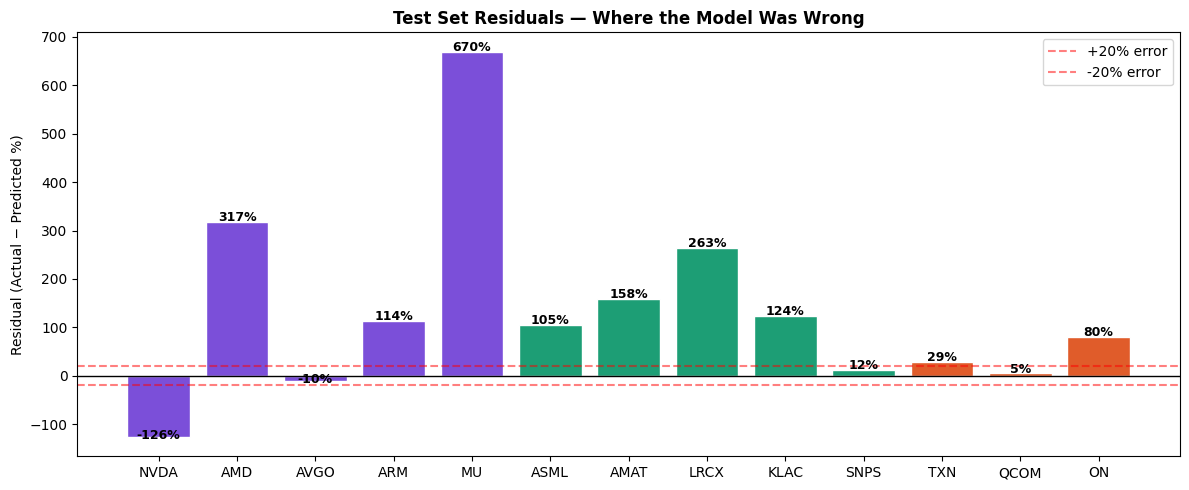

In [26]:
# Residuals = actual return minus predicted return
# Large residuals = stocks the model got very wrong
# Understanding WHY it got them wrong is often the most valuable finding

test_df = test_df.copy()
test_df['Predicted']  = y_test_pred
test_df['Residual']   = y_test - y_test_pred
test_df['Abs_Error']  = test_df['Residual'].abs()

print('Test set — actual vs predicted:')
print('=' * 70)
display_cols = ['Ticker','Group','Fwd_Return','Predicted','Residual']
print(test_df[display_cols].sort_values('Residual', ascending=False).round(1).to_string())

print(f'\nBiggest overestimates (model too optimistic):')
print(test_df.nsmallest(3, 'Residual')[['Ticker','Fwd_Return','Predicted','Residual']].round(1))

print(f'\nBiggest underestimates (model missed upside):')
print(test_df.nlargest(3, 'Residual')[['Ticker','Fwd_Return','Predicted','Residual']].round(1))

# Plot residuals
fig, ax = plt.subplots(figsize=(12, 5))
colors  = [{'AI Chip Pure Play':'#7B4FD9',
            'AI Chip Enabler':'#1D9E75',
            'Non-AI Control':'#E05C2A'}.get(g,'gray')
           for g in test_df['Group']]

bars = ax.bar(test_df['Ticker'], test_df['Residual'],
              color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(20,  color='red', linestyle='--', alpha=0.5, label='+20% error')
ax.axhline(-20, color='red', linestyle='--', alpha=0.5, label='-20% error')

for bar, val in zip(bars, test_df['Residual']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (2 if val >= 0 else -4),
            f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Residual (Actual − Predicted %)')
ax.set_title('Test Set Residuals — Where the Model Was Wrong',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

##### Step 10: Conclusion

In [27]:
print('=' * 60)
print('REGRESSION FINDINGS')
print('=' * 60)

print(f'''
TRAINING PERFORMANCE (2020-2023):
  R² = {train_r2:.3f}
  The model explains {train_r2*100:.1f}% of return variance
  in the training period.

OUT-OF-SAMPLE TEST (2024 → 2025 returns):
  R² = {test_r2:.3f}
  MAE = {test_mae:.1f}% average prediction error

WHAT THIS MEANS:
  If test R² > 0.15:  model has genuine predictive signal
  If test R² < 0.05:  fundamentals alone don't predict returns
                      in this sector/period
  If train R² >> test R²: model overfit training data

MOST PREDICTIVE FEATURES (by individual R²):''')

sorted_features = sorted(single_results.items(),
                          key=lambda x: x[1]['r2'], reverse=True)
for feat, res in sorted_features:
    direction = 'negative' if res['slope'] < 0 else 'positive'
    print(f'  {feat:<20} R²={res["r2"]:.3f}  '
          f'({direction} relationship)  '
          f'p={res["p_value"]:.4f}')

print(f'''
KEY FINDING:
  Stocks the model got most wrong are the most interesting.
  Large positive residuals = model underestimated → 
    something beyond fundamentals drove the return
    (narrative, momentum, macro event)
  Large negative residuals = model overestimated →
    fundamentals looked good but something went wrong
    (execution, competition, sector rotation)

NOTE: This is exploratory analysis only.
Small sample size (n={len(model_df)}) means results
have wide confidence intervals. Do not use for
actual investment decisions.
''')

REGRESSION FINDINGS

TRAINING PERFORMANCE (2020-2023):
  R² = 0.676
  The model explains 67.6% of return variance
  in the training period.

OUT-OF-SAMPLE TEST (2024 → 2025 returns):
  R² = -0.620
  MAE = 154.9% average prediction error

WHAT THIS MEANS:
  If test R² > 0.15:  model has genuine predictive signal
  If test R² < 0.05:  fundamentals alone don't predict returns
                      in this sector/period
  If train R² >> test R²: model overfit training data

MOST PREDICTIVE FEATURES (by individual R²):
  Rev_Growth           R²=0.481  (positive relationship)  p=0.0060
  Gross_Margin         R²=0.280  (positive relationship)  p=0.0518
  PE_Ratio             R²=0.170  (negative relationship)  p=0.1427
  PS_Ratio             R²=0.057  (positive relationship)  p=0.4107
  EV_EBITDA            R²=0.051  (negative relationship)  p=0.4373

KEY FINDING:
  Stocks the model got most wrong are the most interesting.
  Large positive residuals = model underestimated → 
    something beyo